In [65]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

class Linear_Regression():
    def __init__(self, learning_rate, no_of_iterations):
        self.learning_rate = learning_rate
        self.no_of_iterations = no_of_iterations

    def fit(self, X, Y):
        self.m, self.n = X.shape
        self.w = np.zeros(self.n)
        self.b = 0
        self.X = X
        self.Y = Y

        for i in range(self.no_of_iterations):
            self.update_weights()

    def update_weights(self):
        Y_prediction = self.predict(self.X)
        dw = - (2 * (self.X.T).dot(self.Y - Y_prediction)) / self.m
        db = -2 * np.sum(self.Y - Y_prediction) / self.m

        self.w = self.w - self.learning_rate * dw
        self.b = self.b - self.learning_rate * db

    def predict(self, X):
        return X.dot(self.w) + self.b

In [5]:
df=pd.read_csv('Salary_Data.csv')

In [6]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [7]:
df.shape()

TypeError: 'tuple' object is not callable

In [8]:
df.shape

(6704, 6)

In [9]:
df.tail()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0
6703,26.0,Female,High School,Sales Executive,1.0,35000.0


In [10]:
df.drop('Age',axis=1)

,Gender,Education Level,Job Title,Years of Experience,Salary
0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,Female,Master's,Data Analyst,3.0,65000.0
2,Male,PhD,Senior Manager,15.0,150000.0
3,Female,Bachelor's,Sales Associate,7.0,60000.0
4,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...
6699,Female,PhD,Director of Marketing,20.0,200000.0
6700,Male,High School,Sales Associate,3.0,50000.0
6701,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,Male,Master's Degree,Marketing Manager,14.0,140000.0


In [11]:
df.drop('Gender',axis=1)

,Age,Education Level,Job Title,Years of Experience,Salary
0,32.0,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Master's,Data Analyst,3.0,65000.0
2,45.0,PhD,Senior Manager,15.0,150000.0
3,36.0,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Master's,Director,20.0,200000.0
...,...,...,...,...,...
6699,49.0,PhD,Director of Marketing,20.0,200000.0
6700,32.0,High School,Sales Associate,3.0,50000.0
6701,30.0,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Master's Degree,Marketing Manager,14.0,140000.0


In [12]:
df.drop('Age',axis=1,inplace=True)

In [13]:
df.head()

,Gender,Education Level,Job Title,Years of Experience,Salary
0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,Female,Master's,Data Analyst,3.0,65000.0
2,Male,PhD,Senior Manager,15.0,150000.0
3,Female,Bachelor's,Sales Associate,7.0,60000.0
4,Male,Master's,Director,20.0,200000.0


In [14]:
df.drop('Gender',axis=1,inplace=True)
df.drop('Education Level',axis=1,inplace=True)
df.drop('Job Title',axis=1,inplace=True)

In [15]:
df.head()

,Years of Experience,Salary
0,5.0,90000.0
1,3.0,65000.0
2,15.0,150000.0
3,7.0,60000.0
4,20.0,200000.0


In [16]:
import seaborn as sns

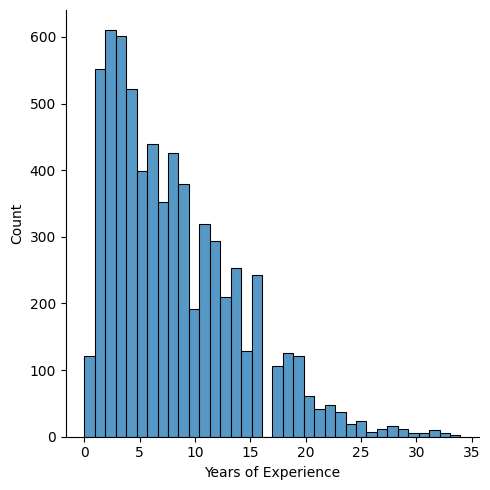

In [17]:
sns.displot(df['Years of Experience'])

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Years of Experience  6701 non-null   float64
 1   Salary               6699 non-null   float64
dtypes: float64(2)
memory usage: 104.9 KB


In [20]:
df.sum().isnull()

,0
Years of Experience,False
Salary,False


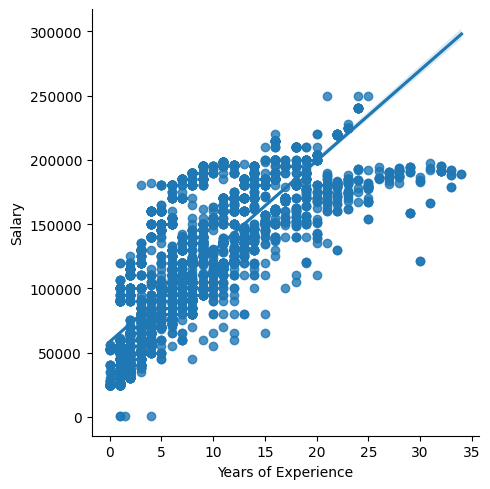

In [22]:

sns.lmplot(x="Years of Experience",y="Salary",data=df)
plt.show()

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Years of Experience  6701 non-null   float64
 1   Salary               6699 non-null   float64
dtypes: float64(2)
memory usage: 104.9 KB


In [24]:
df.sum().isnull()

,0
Years of Experience,False
Salary,False


In [25]:
df.shape

(6704, 2)

In [26]:
df.isnull().sum()

,0
Years of Experience,3
Salary,5


In [27]:
df.dropna(inplace=True)

In [28]:
df.shape

(6699, 2)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6699 entries, 0 to 6703
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Years of Experience  6699 non-null   float64
 1   Salary               6699 non-null   float64
dtypes: float64(2)
memory usage: 157.0 KB


In [67]:
X = df.iloc[:, :-1].values
Y = df.iloc[:, -1].values



# Split data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.33, random_state=2)

# Optional: Normalize
X_train = (X_train - np.mean(X_train, axis=0)) / np.std(X_train, axis=0)
X_test = (X_test - np.mean(X_test, axis=0)) / np.std(X_test, axis=0)

# Train model
model = Linear_Regression(learning_rate=0.02, no_of_iterations=1000)
model.fit(X_train, Y_train)

print('slope or weight =', model.w)
print('intercept or bias =', model.b)

slope or weight = [42979.32916794]
intercept or bias = 115647.51470588219


In [68]:
test_data_prediction = model.predict(X_test)

In [69]:
print(test_data_prediction)

[173816.32476154 101534.39420848 137675.35948501 ... 130447.16642971
  65393.42893195  87078.00809787]


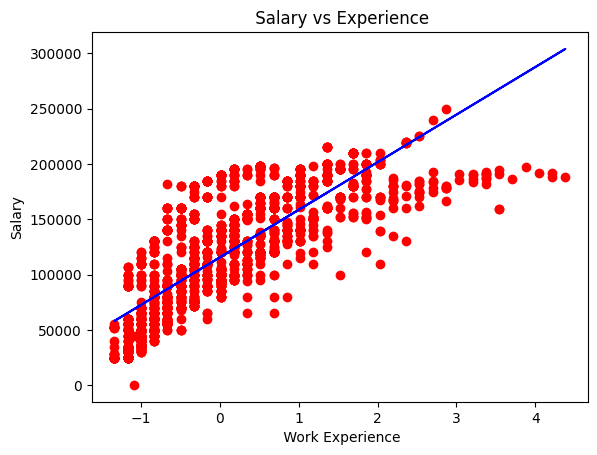

In [72]:
plt.scatter(X_test, Y_test, color = 'red')
plt.plot(X_test, test_data_prediction, color='blue')
plt.xlabel(' Work Experience')
plt.ylabel('Salary')
plt.title(' Salary vs Experience')
plt.show()